# Constant-Population Births Validation

## Purpose

`ConstantPopBirths` adds one new susceptible individual for every death
recorded by `NonDiseaseMortality`, keeping N constant over time.

This notebook validates the component in a spatially-explicit setting:
a **5 × 5 grid of 25 nodes**, each seeded with an active SEIR epidemic.
With balanced births and deaths the total population and the per-node
populations should remain flat throughout 10 years of simulation.

**Pass criterion:** the maximum absolute deviation of N_total(t) from its
initial value should be less than 1% of the initial total population.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from laser.core import PropertySet
from laser.core.utils import grid
from laser.generic.utils import ValuesMap
from laser.cohorts import Model
from laser.cohorts.vitaldynamics import NonDiseaseMortality, ConstantPopBirths
import laser.cohorts.SEIR as SEIR

In [2]:
# --- Parameters ---
grid_rows   = 5
grid_cols   = 5
n_nodes     = grid_rows * grid_cols   # 25
N_per_node  = 10_000
I0_per_node = 10
CDR         = 20          # per 1000/yr
beta_val    = 0.5
gamma       = 0.1         # recovery rate (per day)
sigma       = 0.2         # progression rate (per day; ~5-day latent period)
nticks      = 10 * 365   # 10 years

r_mortality_val = CDR / 1000 / 365

# --- Scenario: 25-node grid, all nodes seeded ---
scenario = grid(M=grid_rows, N=grid_cols)
scenario["S"] = N_per_node - I0_per_node
scenario["E"] = 0
scenario["I"] = I0_per_node
scenario["R"] = 0

# --- Build model ---
params = PropertySet({"nticks": nticks})
model  = Model(scenario, params)

betas          = ValuesMap.from_scalar(beta_val, nticks, n_nodes)
r_progressions = ValuesMap.from_scalar(sigma,    nticks, n_nodes)
r_recoveries   = ValuesMap.from_scalar(gamma,    nticks, n_nodes)

# NonDiseaseMortality must come before ConstantPopBirths
ndm = NonDiseaseMortality(model, r_mortality=r_mortality_val)
cpb = ConstantPopBirths(model)

model.components = [
    SEIR.Susceptible(model),
    SEIR.Exposed(model, r_progression=r_progressions),
    SEIR.Infectious(model, r_recovery=r_recoveries),
    SEIR.Recovered(model),
    ndm,
    cpb,
    SEIR.Transmission(model, beta=betas),
]

print(f"Running SEIR model on {n_nodes} nodes for {nticks} ticks...")

Running SEIR model on 25 nodes for 3650 ticks...


In [3]:
model.run()

# Total population per tick across all nodes
N_total = (
    model.states.S.sum(axis=1)
    + model.states.E.sum(axis=1)
    + model.states.I.sum(axis=1)
    + model.states.R.sum(axis=1)
)

# Per-node population over time — shape (nticks+1, n_nodes)
N_per_node_ts = (
    model.states.S[:, :]
    + model.states.E[:, :]
    + model.states.I[:, :]
    + model.states.R[:, :]
)

print(f"Model run complete.  Initial N_total = {N_total[0]:,}")

Model run complete.  Initial N_total = 250,000


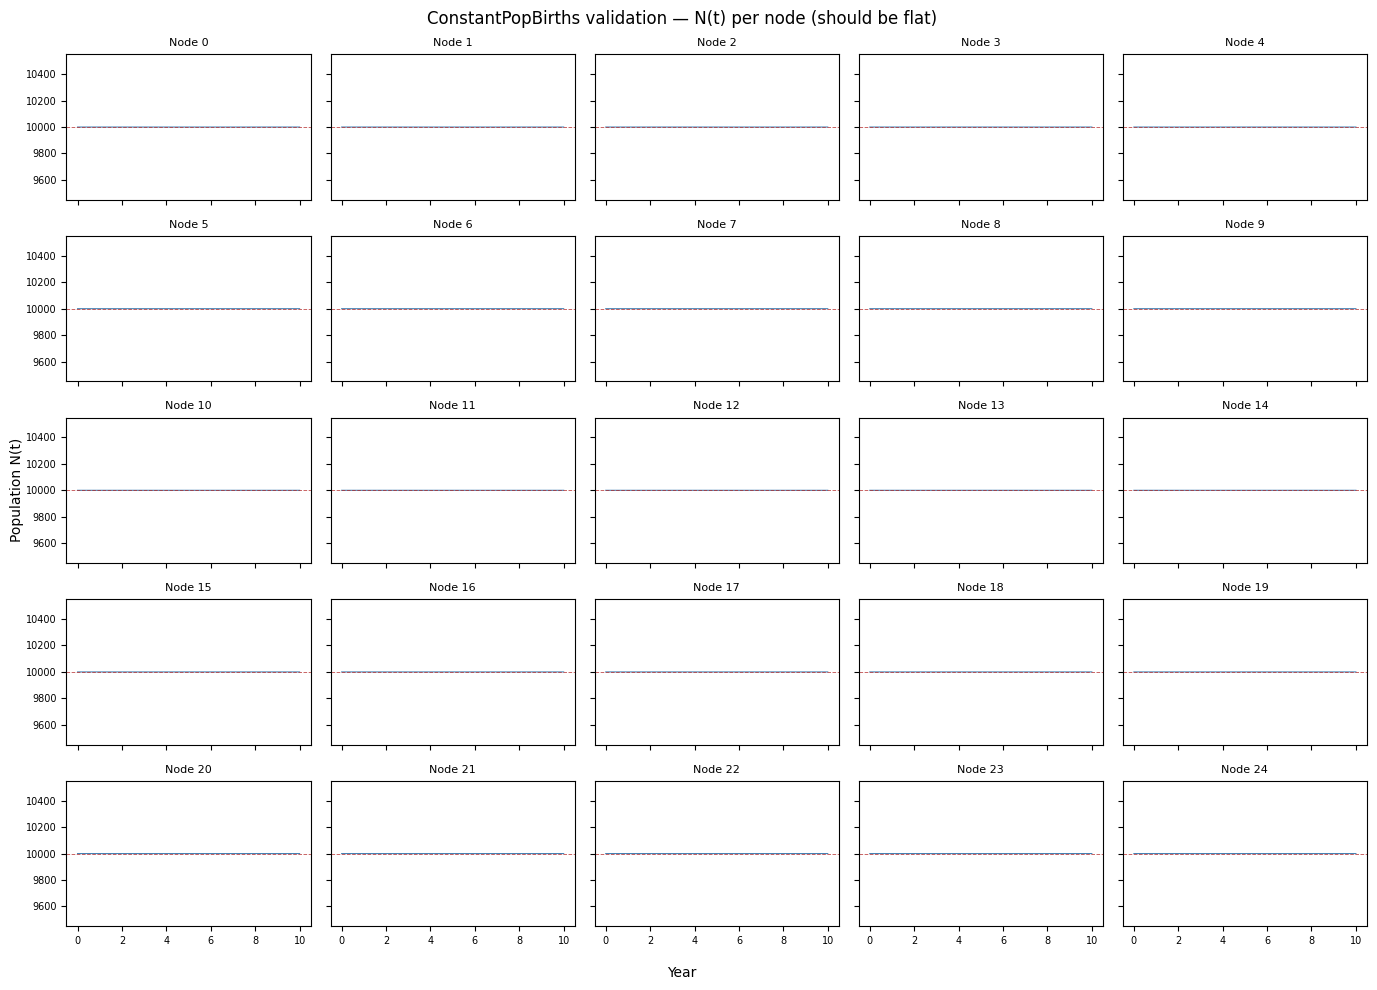

In [4]:
# --- 5×5 subplot grid: N(t) per node ---
t_years = np.arange(nticks + 1) / 365

fig, axes = plt.subplots(grid_rows, grid_cols, figsize=(14, 10), sharex=True, sharey=True)

for node_idx in range(n_nodes):
    row = node_idx // grid_cols
    col = node_idx % grid_cols
    ax  = axes[row, col]
    ax.plot(t_years, N_per_node_ts[:, node_idx], linewidth=0.8, color="steelblue")
    ax.axhline(N_per_node, color="firebrick", linestyle="--", linewidth=0.7, alpha=0.7)
    ax.set_title(f"Node {node_idx}", fontsize=8)
    ax.tick_params(labelsize=7)

fig.supxlabel("Year", fontsize=10)
fig.supylabel("Population N(t)", fontsize=10)
fig.suptitle("ConstantPopBirths validation — N(t) per node (should be flat)", fontsize=12)
plt.tight_layout()
plt.show()

In [5]:
# --- Quantitative check: max deviation of N_total from initial value ---
N_total_0   = N_total[0]
max_dev     = np.abs(N_total - N_total_0).max()
max_dev_pct = max_dev / N_total_0 * 100

print(f"Initial N_total   : {N_total_0:,}")
print(f"Max |N(t) - N(0)| : {max_dev:,}")
print(f"As % of N(0)      : {max_dev_pct:.4f}%")

assert max_dev_pct < 1.0, (
    f"N_total deviates by {max_dev_pct:.4f}% from initial value — "
    "ConstantPopBirths may not be compensating correctly for deaths."
)
print("Max deviation < 1% of initial N_total: OK")

Initial N_total   : 250,000
Max |N(t) - N(0)| : 0
As % of N(0)      : 0.0000%
Max deviation < 1% of initial N_total: OK
